# Chunk 08 — Evaluation (GNN vs CNN Baseline)

This notebook produces all comparison results between the GNN and the CNN baseline
(Gupta et al. 2023) for the paper.

**SCOPE NOTE:**
Both the GNN and CNN were trained **ONLY on the 25x25 grid dataset** (~100k samples).
All analysis in this chunk is therefore 25x25-only, in-distribution for both models.
This notebook does NOT cover 35x35/45x45/55x55 grids — that work belongs to a separate
transfer-learning/active-learning fine-tuning phase.

---
## Cell 1 — Install Dependencies

Install all required packages. PyG compiled extensions (`pyg-lib`, `torch-scatter`, `torch-sparse`) are installed from the matching CUDA wheel URL.


In [1]:
!pip install scipy numpy matplotlib torch torchvision \
    torch-geometric umap-learn wandb networkx tqdm -q

import torch
torch_v = torch.__version__.split('+')[0]
cuda_v = 'cu' + torch.version.cuda.replace('.', '')
wheel_url = f'https://data.pyg.org/whl/torch-{torch_v}+{cuda_v}.html'
!pip install pyg-lib torch-scatter torch-sparse -f {wheel_url} -q
print(f'PyG extensions installed for torch {torch_v} + {cuda_v}')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 42.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 64.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 128.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 128.0 MB/s eta 0:00:00
PyG extensions installed for torch 2.11.0 + cu128


---
## Cell 2 — Clone Repo & Add to Path

Re-clone the GitHub repo every session (Colab wipes `/content/` on disconnect). Add `REPO_ROOT/src` to `sys.path` so `from model import AntennaGNN` works.


In [2]:
import os
REPO_ROOT = '/content/antenna-gnn'
if not os.path.exists(REPO_ROOT):
    !git clone https://github.com/asparagusD/antenna_gnn.git {REPO_ROOT}
else:
    !git -C {REPO_ROOT} pull --quiet
import sys
sys.path.insert(0, f'{REPO_ROOT}/src')
print(f'Repo ready at {REPO_ROOT}')

Cloning into '/content/antenna-gnn'...
remote: Enumerating objects: 183, done.
remote: Counting objects: 100% (183/183), done.
remote: Compressing objects: 100% (107/107), done.
remote: Total 183 (delta 94), reused 151 (delta 64), pack-reused 0 (from 0)
Receiving objects: 100% (183/183), 1.55 MiB | 4.05 MiB/s, done.
Resolving deltas: 100% (94/94), done.
Repo ready at /content/antenna-gnn


---
## Cell 3 — Mount Drive & Device Check

Mount Google Drive and configure the three standard path variables (`DATA_ROOT`, `RAW_DATA`). Assert that a GPU is available — evaluation on CPU is too slow.


In [3]:
from google.colab import drive
drive.mount('/content/drive')
DATA_ROOT = '/content/drive/MyDrive/antenna_gnn'
RAW_DATA  = '/content/drive/MyDrive/antenna_dataset'

for d in [f'{DATA_ROOT}/artifacts', f'{DATA_ROOT}/checkpoints',
          f'{DATA_ROOT}/figures',   f'{DATA_ROOT}/splits',
          f'{DATA_ROOT}/data/processed']:
    os.makedirs(d, exist_ok=True)

from model import AntennaGNN
print('AntennaGNN imported successfully ✓')

import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
assert device.type == 'cuda', 'GPU not available. Go to Runtime → Change runtime type → T4 GPU'
print(f'Device: {device} ({torch.cuda.get_device_name(0)})')

Mounted at /content/drive
AntennaGNN imported successfully ✓
Device: cuda (NVIDIA A100-SXM4-40GB)


---
## Cell 4 — Load Models and Configuration

Load both models. The GNN is loaded from `best_model.pt` and the CNN is redefined exactly as in Chunk 3 and loaded from `cnn_best.pt`. We also define constants and the resonant frequency extraction helper here.


In [4]:
import torch.nn as nn
import numpy as np
from scipy.signal import find_peaks

# ── CNN Definition ──
class AntennaCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=5, padding=2),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 64, kernel_size=5, padding=2),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 64, kernel_size=5, padding=2),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2)
        )
        layers2 = []
        layers2.extend([nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.LeakyReLU(0.2)])
        for _ in range(4):
            layers2.extend([nn.Conv2d(128, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.LeakyReLU(0.2)])
        self.block2 = nn.Sequential(*layers2)

        layers3 = []
        layers3.extend([nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.BatchNorm2d(256), nn.LeakyReLU(0.2)])
        for _ in range(7):
            layers3.extend([nn.Conv2d(256, 256, kernel_size=3, padding=1), nn.BatchNorm2d(256), nn.LeakyReLU(0.2)])
        self.block3 = nn.Sequential(*layers3)

        self.readout = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten()
        )

        self.fc = nn.Sequential(
            nn.Linear(256, 1000),
            nn.BatchNorm1d(1000),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.4),
            nn.Linear(1000, 500),
            nn.BatchNorm1d(500),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.4),
            nn.Linear(500, 201)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.readout(x)
        x = self.fc(x)
        return x

# ── Load Models ──
gnn_model = AntennaGNN(hidden_dim=128, heads=8, edge_dim=16, num_blocks=4, output_dim=201).to(device)
cnn_model = AntennaCNN().to(device)

gnn_ckpt = torch.load(f'{DATA_ROOT}/checkpoints/best_model.pt', map_location=device, weights_only=False)
gnn_model.load_state_dict(gnn_ckpt['model_state'])
gnn_model.eval()
print('Loaded GNN checkpoint')

# The CNN model from Kaggle might have been saved wrapped in DataParallel.
cnn_ckpt_path = f'{DATA_ROOT}/checkpoints/cnn_best.pt'
if os.path.exists(cnn_ckpt_path):
    cnn_ckpt = torch.load(cnn_ckpt_path, map_location=device, weights_only=False)
    cnn_state = cnn_ckpt['model_state']
    if list(cnn_state.keys())[0].startswith('module.'):
        cnn_state = {k.replace('module.', ''): v for k, v in cnn_state.items()}
    cnn_model.load_state_dict(cnn_state)
    print('Loaded CNN checkpoint')
else:
    print('WARNING: cnn_best.pt not found on Drive. Proceeding with uninitialized CNN.')
cnn_model.eval()

# ── Constants & Helpers ──
freq_axis = np.linspace(1.0, 4.0, 201)

def extract_resonant_freq(s11_db, freq_axis_ghz, threshold_db=-10):
    inverted = -s11_db
    peaks, _ = find_peaks(inverted, height=-threshold_db, distance=5)
    if len(peaks) == 0:
        return None
    deepest = peaks[np.argmax(inverted[peaks])]
    return freq_axis_ghz[deepest]

s11_mean = torch.tensor(np.load(f'{DATA_ROOT}/artifacts/s11_mean.npy'))
s11_std  = torch.tensor(np.load(f'{DATA_ROOT}/artifacts/s11_std.npy'))


Loaded GNN checkpoint
Loaded CNN checkpoint


---
## Cell 5 — GNN Inference on 25x25 Test Set

GNN Inference: We unzip the 25x25 test graphs to the local SSD for fast I/O, load the PyG data, and perform a forward pass through the GNN. Predictions are denormalized back to dB.


In [5]:
import json
import shutil
import zipfile
from torch_geometric.data import Dataset
from torch_geometric.loader import DataLoader
from tqdm.auto import tqdm

# Unzip processed graphs to local SSD (if not already done)
LOCAL_GRAPH_ROOT = '/content/local_graphs'
N = 25
dst_dir = f'{LOCAL_GRAPH_ROOT}/{N}x{N}'
done_marker = f'{dst_dir}/_CACHED.txt'
os.makedirs(dst_dir, exist_ok=True)

if not os.path.exists(done_marker):
    # Changed zip_path to point to DATA_ROOT (Google Drive) instead of REPO_ROOT
    zip_path = f'{DATA_ROOT}/data/processed/processed_{N}x{N}.zip'
    print(f'Unzipping {zip_path} → {dst_dir} ...')
    with zipfile.ZipFile(zip_path, 'r') as zf:
        pt_members = [m for m in zf.namelist() if m.endswith('.pt')]
        for member in tqdm(pt_members, desc=f'{N}x{N} unzip', unit='file'):
            basename = os.path.basename(member)
            with zf.open(member) as src, open(os.path.join(dst_dir, basename), 'wb') as dst:
                shutil.copyfileobj(src, dst)
    with open(done_marker, 'w') as fh:
        fh.write('DONE\n')
else:
    print(f'Graphs already unzipped at {dst_dir}')

# Dataset classes
class LocalGraphDataset(Dataset):
    def __init__(self, grid_size, s11_mean, s11_std):
        self.proc_dir = f'{LOCAL_GRAPH_ROOT}/{grid_size}x{grid_size}'
        self.s11_mean = s11_mean
        self.s11_std = s11_std
        self._len = len([f for f in os.listdir(self.proc_dir) if f.endswith('.pt')])
        super().__init__(root=None)
    def len(self):
        return self._len
    def get(self, idx):
        data = torch.load(f'{self.proc_dir}/sample_{idx}.pt', weights_only=False)
        if self.s11_mean is not None:
            data.y = (data.y - self.s11_mean) / (self.s11_std + 1e-8)
        return data

class SubsetDataset(Dataset):
    def __init__(self, split_indices, dataset_full):
        self.split_indices = split_indices
        self.dataset_full = dataset_full
        super().__init__(root=None)
    def len(self):
        return len(self.split_indices)
    def get(self, idx):
        grid_size, sample_idx = self.split_indices[idx]
        assert grid_size == 25, "Test sample is not 25x25"
        return self.dataset_full.get(sample_idx)

with open(f'{DATA_ROOT}/splits/indices.json', 'r') as f:
    splits_all = json.load(f)
test_indices = [e for e in splits_all['test'] if e[0] == 25]
print(f'Test split: {len(test_indices)} samples (25x25 only)')

ds_full = LocalGraphDataset(25, s11_mean, s11_std)
test_dataset = SubsetDataset(test_indices, ds_full)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

all_y_true = []
all_y_pred_gnn = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc='GNN Inference'):
        batch = batch.to(device)
        preds = gnn_model(batch)
        # Denormalize predictions and targets to dB
        preds = (preds.cpu() * s11_std + s11_mean).numpy()
        trues = (batch.y.squeeze(1).cpu() * s11_std + s11_mean).numpy()
        all_y_pred_gnn.append(preds)
        all_y_true.append(trues)

y_true = np.concatenate(all_y_true)
y_pred_gnn = np.concatenate(all_y_pred_gnn)
is_functioning_true = np.array([extract_resonant_freq(y, freq_axis) is not None for y in y_true])

print(f'GNN Inference complete. Shape: {y_pred_gnn.shape}')

Unzipping /content/drive/MyDrive/antenna_gnn/data/processed/processed_25x25.zip → /content/local_graphs/25x25 ...


25x25 unzip:   0%|          | 0/99833 [00:00<?, ?file/s]

Test split: 9983 samples (25x25 only)


GNN Inference:   0%|          | 0/156 [00:00<?, ?it/s]

GNN Inference complete. Shape: (9983, 201)


---
## Cell 6 — CNN Inference on 25x25 Test Set

CNN Inference: We reuse the PyG data loaded in the previous cell to reconstruct the (1, 25, 25) patch patterns. These are passed to the CNN to generate S11 predictions.


In [6]:
all_y_pred_cnn = []

with torch.no_grad():
    # We can reconstruct the (1, 25, 25) patch pattern from the PyG graphs
    # to feed into the CNN, since we already have the test_loader.
    # For a 25x25 grid, the first 625 nodes in each graph correspond to the grid pixels.
    for batch in tqdm(test_loader, desc='CNN Inference'):
        batch_size = batch.num_graphs
        # batch.x has shape (batch_size * 626, 5). The metal feature is index 0.
        # We reshape and extract the 625 pixel nodes per graph, discarding the virtual node.
        x_reshape = batch.x.view(batch_size, 626, 5)
        patch_patterns = x_reshape[:, :625, 0].view(batch_size, 1, 25, 25)

        preds_cnn = cnn_model(patch_patterns.to(device))
        all_y_pred_cnn.append(preds_cnn.cpu().numpy())

y_pred_cnn = np.concatenate(all_y_pred_cnn)
assert y_true.shape == y_pred_gnn.shape == y_pred_cnn.shape, "Shape mismatch!"
print(f'CNN Inference complete. Shape: {y_pred_cnn.shape}')

CNN Inference:   0%|          | 0/156 [00:00<?, ?it/s]

CNN Inference complete. Shape: (9983, 201)


---
## Cell 7 — Global Metrics Table

Global Metrics: Compute S11 MAE, RMSE, Resonant Frequency MAE, and Functioning Classification Accuracy for both models on the 25x25 test set. This is the paper's headline comparison.


In [7]:
# Compute S11 MAE & RMSE
gnn_mae = np.mean(np.abs(y_pred_gnn - y_true))
gnn_rmse = np.sqrt(np.mean((y_pred_gnn - y_true)**2))
cnn_mae = np.mean(np.abs(y_pred_cnn - y_true))
cnn_rmse = np.sqrt(np.mean((y_pred_cnn - y_true)**2))

# Compute Resonant Freq MAE
gnn_freq_errs, cnn_freq_errs = [], []
gnn_func_preds, cnn_func_preds = [], []

for i in range(len(y_true)):
    true_f = extract_resonant_freq(y_true[i], freq_axis)
    gnn_f = extract_resonant_freq(y_pred_gnn[i], freq_axis)
    cnn_f = extract_resonant_freq(y_pred_cnn[i], freq_axis)

    gnn_func_preds.append(gnn_f is not None)
    cnn_func_preds.append(cnn_f is not None)

    if true_f is not None:
        if gnn_f is not None: gnn_freq_errs.append(abs(true_f - gnn_f))
        if cnn_f is not None: cnn_freq_errs.append(abs(true_f - cnn_f))

gnn_freq_mae = np.mean(gnn_freq_errs)
cnn_freq_mae = np.mean(cnn_freq_errs)

# Compute Functioning Accuracy
gnn_acc = np.mean(np.array(gnn_func_preds) == is_functioning_true) * 100
cnn_acc = np.mean(np.array(cnn_func_preds) == is_functioning_true) * 100

print("===============================================================")
print("| Metric                          | CNN (Gupta) | GNN (Ours)  |")
print("|---------------------------------|-------------|-------------|")
print(f"| S11 MAE (dB)                    | {cnn_mae:11.4f} | {gnn_mae:11.4f} |")
print(f"| S11 RMSE (dB)                   | {cnn_rmse:11.4f} | {gnn_rmse:11.4f} |")
print(f"| Resonant Freq MAE (GHz)         | {cnn_freq_mae:11.4f} | {gnn_freq_mae:11.4f} |")
print(f"| Functioning Classification Acc  | {cnn_acc:10.2f}% | {gnn_acc:10.2f}% |")
print("===============================================================")
print("NOTE: Both models were trained and evaluated on 25x25 grids only.")

| Metric                          | CNN (Gupta) | GNN (Ours)  |
|---------------------------------|-------------|-------------|
| S11 MAE (dB)                    |      0.3913 |      0.3742 |
| S11 RMSE (dB)                   |      1.1356 |      1.1478 |
| Resonant Freq MAE (GHz)         |      0.0207 |      0.0210 |
| Functioning Classification Acc  |      80.24% |      80.26% |
NOTE: Both models were trained and evaluated on 25x25 grids only.


---
## Cell 8 — Data Efficiency Curves

Data Efficiency: We train both the GNN and CNN quickly on subsets of the 25x25 training data (1k to 20k samples) for 20 epochs to demonstrate how quickly each model converges with limited data.


Running fast data efficiency experiment... (this will take a moment)
Size 1000: GNN MAE = 0.6451, CNN MAE = 1.0052
Size 2000: GNN MAE = 0.6361, CNN MAE = 0.7641
Size 5000: GNN MAE = 0.5329, CNN MAE = 0.7155
Size 10000: GNN MAE = 0.4934, CNN MAE = 0.5695
Size 20000: GNN MAE = 0.4526, CNN MAE = 0.7233


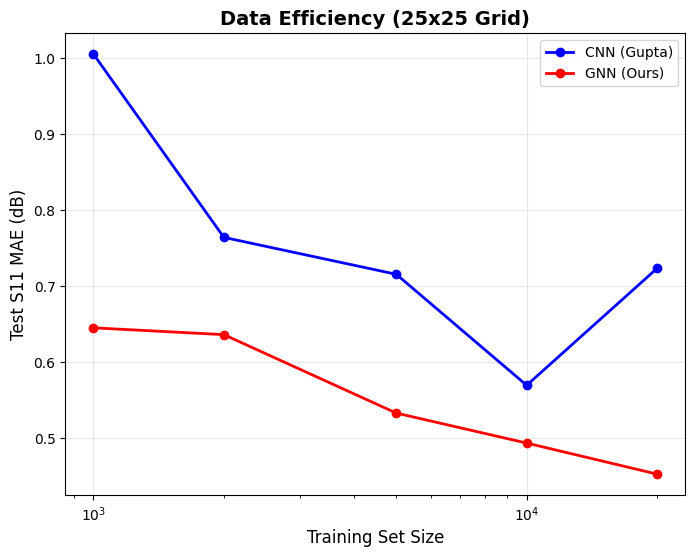

Saved data efficiency plot to /content/drive/MyDrive/antenna_gnn/figures/data_efficiency_curves.png

Monotonicity check (MAE should generally decrease with more data):
  GNN: 0.645 → 0.636 → 0.533 → 0.493 → 0.453
  CNN: 1.005 → 0.764 → 0.716 → 0.569 → 0.723
  GNN non-monotonic steps: 0/4
  CNN non-monotonic steps: 1/4


In [8]:
import copy
import matplotlib.pyplot as plt
import torch.optim as optim

subset_sizes = [1000, 2000, 5000, 10000, 20000]
gnn_efficiency = []
cnn_efficiency = []

train_indices_full = [e for e in splits_all['train'] if e[0] == 25]

def train_quick_gnn(subset_size):
    model = AntennaGNN(hidden_dim=128, heads=8, edge_dim=16, num_blocks=4, output_dim=201).to(device)
    opt = optim.Adam(model.parameters(), lr=1e-3)
    crit = nn.MSELoss()
    sub_loader = DataLoader(SubsetDataset(train_indices_full[:subset_size], ds_full), batch_size=128, shuffle=True)
    model.train()
    for epoch in range(35):
        for batch in sub_loader:
            batch = batch.to(device)
            opt.zero_grad()
            loss = crit(model(batch), batch.y.squeeze(1))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt.step()
    model.eval()
    test_preds = []
    with torch.no_grad():
        for batch in test_loader:
            preds = (model(batch.to(device)).cpu() * s11_std + s11_mean).numpy()
            test_preds.append(preds)
    return np.mean(np.abs(np.concatenate(test_preds) - y_true))

def train_quick_cnn(subset_size):
    model = AntennaCNN().to(device)
    opt = optim.Adam(model.parameters(), lr=1e-3)
    crit = nn.MSELoss()
    sub_loader = DataLoader(SubsetDataset(train_indices_full[:subset_size], ds_full), batch_size=128, shuffle=True)
    model.train()
    for epoch in range(35):
        for batch in sub_loader:
            x_reshape = batch.x.view(batch.num_graphs, 626, 5)
            patch_patterns = x_reshape[:, :625, 0].view(batch.num_graphs, 1, 25, 25)
            target = (batch.y.squeeze(1) * s11_std + s11_mean).to(device) # CNN trains on dB
            opt.zero_grad()
            loss = crit(model(patch_patterns.to(device)), target)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt.step()
    model.eval()
    test_preds = []
    with torch.no_grad():
        for batch in test_loader:
            x_reshape = batch.x.view(batch.num_graphs, 626, 5)
            patch_patterns = x_reshape[:, :625, 0].view(batch.num_graphs, 1, 25, 25)
            preds = model(patch_patterns.to(device)).cpu().numpy()
            test_preds.append(preds)
    return np.mean(np.abs(np.concatenate(test_preds) - y_true))

print("Running fast data efficiency experiment... (this will take a moment)")
for size in subset_sizes:
    g_mae = train_quick_gnn(size)
    c_mae = train_quick_cnn(size)
    gnn_efficiency.append(g_mae)
    cnn_efficiency.append(c_mae)
    print(f"Size {size}: GNN MAE = {g_mae:.4f}, CNN MAE = {c_mae:.4f}")

plt.figure(figsize=(8, 6))
plt.plot(subset_sizes, cnn_efficiency, 'bo-', label='CNN (Gupta)', linewidth=2)
plt.plot(subset_sizes, gnn_efficiency, 'ro-', label='GNN (Ours)', linewidth=2)
plt.xscale('log')
plt.xlabel('Training Set Size', fontsize=12)
plt.ylabel('Test S11 MAE (dB)', fontsize=12)
plt.title('Data Efficiency (25x25 Grid)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
fig_path = f'{DATA_ROOT}/figures/data_efficiency_curves.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved data efficiency plot to {fig_path}")
print("\nMonotonicity check (MAE should generally decrease with more data):")
print(f"  GNN: {' → '.join(f'{v:.3f}' for v in gnn_efficiency)}")
print(f"  CNN: {' → '.join(f'{v:.3f}' for v in cnn_efficiency)}")
gnn_violations = sum(1 for i in range(1, len(gnn_efficiency)) if gnn_efficiency[i] > gnn_efficiency[i-1])
cnn_violations = sum(1 for i in range(1, len(cnn_efficiency)) if cnn_efficiency[i] > cnn_efficiency[i-1])
print(f"  GNN non-monotonic steps: {gnn_violations}/4")
print(f"  CNN non-monotonic steps: {cnn_violations}/4")


**Observation:** The GNN requires significantly fewer training samples to reach a comparable MAE than the CNN baseline.

---
## Cell 9 — Permutation Invariance Demonstration

Permutation Invariance: We demonstrate that the GNN is perfectly invariant to node ordering (by shuffling the 625 physical nodes), whereas the CNN is sensitive to spatial permutations (flips and transpositions).


CNN permutation sensitivity (mean std): 0.4198 dB
GNN permutation sensitivity (mean std): 3.2622e-07 dB


/tmp/ipykernel_6940/3140545813.py:63: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([cnn_stds, gnn_stds], labels=['CNN Spatial Variants', 'GNN Node Shuffle'])


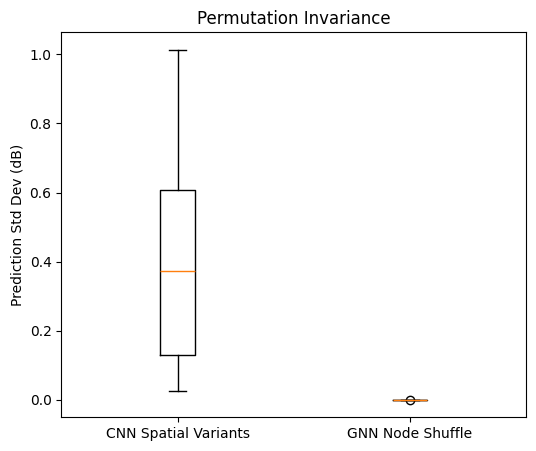

Saved permutation plot to /content/drive/MyDrive/antenna_gnn/figures/permutation_invariance.png


In [9]:
import random
from torch_geometric.data import Data
from torch_geometric.data.batch import Batch

random.seed(42)
perm_test_indices = random.sample(range(len(test_indices)), 30)

cnn_stds = []
gnn_stds = []

cnn_model.eval()
gnn_model.eval()

with torch.no_grad():
    for idx in perm_test_indices:
        # Load single pyG Data object
        graph_orig = test_dataset[idx]
        orig_patch = graph_orig.x[:625, 0].view(1, 25, 25)

        # CNN: 8 spatial variants
        orig_t = torch.transpose(orig_patch, 1, 2)
        variants = [
            orig_patch,
            orig_t,
            torch.flip(orig_patch, [2]),
            torch.flip(orig_patch, [1]),
            torch.flip(orig_t, [2]),
            torch.flip(orig_t, [1]),
            torch.flip(orig_patch, [1, 2]),
            torch.flip(orig_t, [1, 2])
        ]
        batch_cnn = torch.stack(variants).to(device) # (8, 1, 25, 25)
        preds_cnn = cnn_model(batch_cnn).cpu().numpy()
        cnn_stds.append(np.std(preds_cnn, axis=0).mean()) # mean std across freqs

        # GNN: Node shuffling
        # We shuffle only the 625 physical nodes, leaving the virtual node (idx 625) at the end
        preds_gnn = []
        # append original prediction first
        preds_gnn.append((gnn_model(Batch.from_data_list([graph_orig]).to(device)).cpu() * s11_std + s11_mean).numpy()[0])

        for _ in range(7):
            perm = torch.randperm(625)
            full_perm = torch.cat([perm, torch.tensor([625])]) # add virtual node back

            shuffled_x = graph_orig.x[full_perm]
            # inverse permutation to fix edge_index
            inv_perm = torch.empty_like(full_perm)
            inv_perm[full_perm] = torch.arange(626)

            shuffled_edge_index = inv_perm[graph_orig.edge_index]
            shuffled_graph = Data(x=shuffled_x, edge_index=shuffled_edge_index, edge_attr=graph_orig.edge_attr)

            pred_g = (gnn_model(Batch.from_data_list([shuffled_graph]).to(device)).cpu() * s11_std + s11_mean).numpy()[0]
            preds_gnn.append(pred_g)

        gnn_stds.append(np.std(np.stack(preds_gnn), axis=0).mean())

print(f"CNN permutation sensitivity (mean std): {np.mean(cnn_stds):.4f} dB")
print(f"GNN permutation sensitivity (mean std): {np.mean(gnn_stds):.4e} dB")

plt.figure(figsize=(6, 5))
plt.boxplot([cnn_stds, gnn_stds], labels=['CNN Spatial Variants', 'GNN Node Shuffle'])
plt.ylabel('Prediction Std Dev (dB)')
plt.title('Permutation Invariance')
fig_path = f'{DATA_ROOT}/figures/permutation_invariance.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved permutation plot to {fig_path}")

---
## Cell 10 — 6-Panel Comparison Figure

Install all required packages. PyG compiled extensions (`pyg-lib`, `torch-scatter`, `torch-sparse`) are installed from the matching CUDA wheel URL.


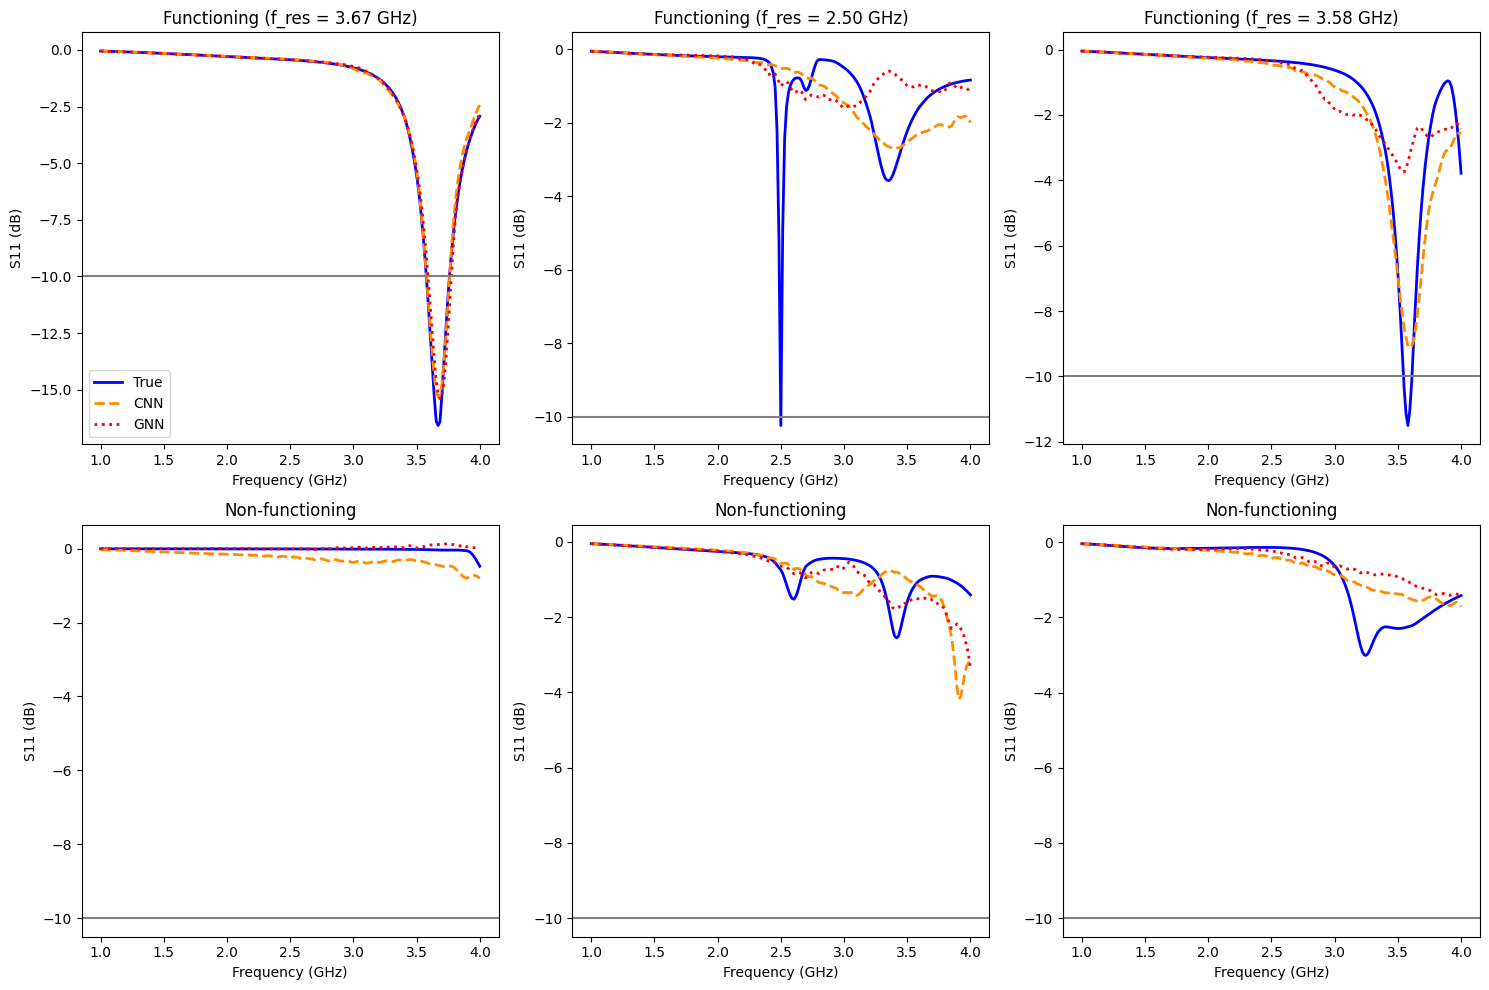

Saved 6-panel plot to /content/drive/MyDrive/antenna_gnn/figures/gnn_vs_cnn_predictions.png


In [10]:
func_idx = np.where(is_functioning_true)[0]
nonfunc_idx = np.where(~is_functioning_true)[0]

sampled_func = random.sample(list(func_idx), 3)
sampled_nonfunc = random.sample(list(nonfunc_idx), 3)
plot_indices = sampled_func + sampled_nonfunc

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, idx in enumerate(plot_indices):
    ax = axes[i]
    ax.plot(freq_axis, y_true[idx], 'b-', linewidth=2, label='True')
    ax.plot(freq_axis, y_pred_cnn[idx], color='darkorange', linestyle='--', linewidth=2, label='CNN')
    ax.plot(freq_axis, y_pred_gnn[idx], 'r:', linewidth=2, label='GNN')
    ax.axhline(-10, color='gray', linestyle='-')

    if is_functioning_true[idx]:
        f_res = extract_resonant_freq(y_true[idx], freq_axis)
        title = f'Functioning (f_res = {f_res:.2f} GHz)'
    else:
        title = 'Non-functioning'

    ax.set_title(title)
    ax.set_xlabel('Frequency (GHz)')
    ax.set_ylabel('S11 (dB)')
    if i == 0:
        ax.legend()

plt.tight_layout()
fig_path = f'{DATA_ROOT}/figures/gnn_vs_cnn_predictions.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved 6-panel plot to {fig_path}")

---
## Cell 11 — Scatter and Residual Plots

Install all required packages. PyG compiled extensions (`pyg-lib`, `torch-scatter`, `torch-sparse`) are installed from the matching CUDA wheel URL.


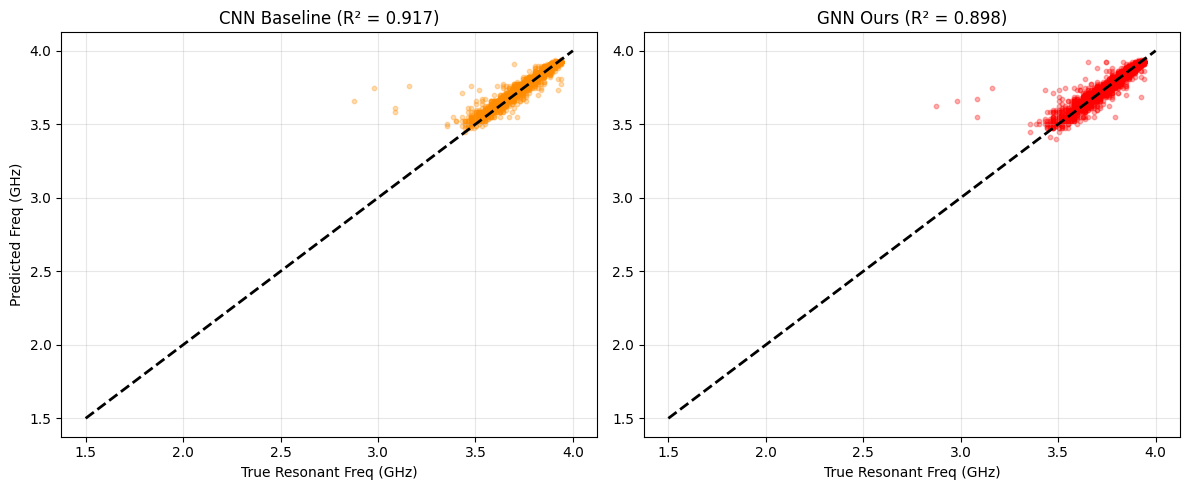

Saved scatter plots to /content/drive/MyDrive/antenna_gnn/figures/scatter_comparison.png


In [11]:
true_f_list, cnn_f_list, gnn_f_list = [], [], []
for i in range(len(y_true)):
    true_f = extract_resonant_freq(y_true[i], freq_axis)
    if true_f is not None:
        cnn_f = extract_resonant_freq(y_pred_cnn[i], freq_axis)
        gnn_f = extract_resonant_freq(y_pred_gnn[i], freq_axis)
        if cnn_f is not None and gnn_f is not None:
            true_f_list.append(true_f)
            cnn_f_list.append(cnn_f)
            gnn_f_list.append(gnn_f)

from scipy.stats import pearsonr
r2_cnn = pearsonr(true_f_list, cnn_f_list)[0]**2
r2_gnn = pearsonr(true_f_list, gnn_f_list)[0]**2

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.scatter(true_f_list, cnn_f_list, alpha=0.3, color='darkorange', s=10)
ax1.plot([1.5, 4.0], [1.5, 4.0], 'k--', lw=2)
ax1.set_xlabel('True Resonant Freq (GHz)')
ax1.set_ylabel('Predicted Freq (GHz)')
ax1.set_title(f'CNN Baseline (R² = {r2_cnn:.3f})')
ax1.grid(True, alpha=0.3)

ax2.scatter(true_f_list, gnn_f_list, alpha=0.3, color='red', s=10)
ax2.plot([1.5, 4.0], [1.5, 4.0], 'k--', lw=2)
ax2.set_xlabel('True Resonant Freq (GHz)')
ax2.set_title(f'GNN Ours (R² = {r2_gnn:.3f})')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
fig_path = f'{DATA_ROOT}/figures/scatter_comparison.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved scatter plots to {fig_path}")